In [77]:
import math

def disc_int_monomial(i, j):
    """
    Computes the function J(2k, 2l) based on the provided formula.
    
    Args:
        k (int): Non-negative integer k
        l (int): Non-negative integer l
        
    Returns:
        float: The result of the J(2k, 2l) calculation
    """
    if i % 2 == 1 or j % 2 == 1:
        return 0

    k, l = i//2, j//2

    k, l = (l, k) if l < k else (k, l)

    # Constant term: pi / (4^(k+l) * (k + l + 1))
    constant_factor = math.pi / (4**(k + l) * (k + l + 1))
    
    # Summation from m = l - k to l + k
    summation = 0
    for m in range(l - k, l + k + 1):
        # Calculate (-1)^(l+m)
        sign = (-1)**(l + m)
        
        # Calculate binomial coefficients (2l choose m) and (2k choose k+l-m)
        # Note: comb(n, k) returns 0 if k < 0 or k > n, matching standard math behaviour
        
        term = sign * math.comb(2 * l, m) * math.comb(2 * k, k + l - m)
        summation += term
        
    return constant_factor * summation


disc_int_monomial(2,0)

0.7853981633974483

In [81]:
import numpy as np
np.set_printoptions(legacy='1.25')

def extend_disc_rule(u0):
    """
    Compute the extended disc rule
    """
    out = []

    for row in u0:
        coords = set()

        x = row[0]
        y = row[1]
        w = row[2]

        coords.add((x, y))
        coords.add((-x, y))
        coords.add((x, -y))
        coords.add((-x, -y))

        coords.add((y, x))
        coords.add((-y, x))
        coords.add((y, -x))
        coords.add((-y, -x))

        coord_type = 0

        if len(coords) == 8:
            coord_type = 3
        elif len(coords) == 4 and x == y and y != 0:
            coord_type = 2
        elif len(coords) == 4:
            coord_type = 1

        for coord in coords:
            out.append([coord[0], coord[1], w, coord_type])


    return np.array(out)


kim_song_rule0 = np.array([
    [0,0,0.114983341799985660],
    [0.42463390374323367,0,0.087938325357145539],
    [0.69446902308083445,0,0.076206570461793249],
    [0.88696766316393713,0,0.042666281539386779],
    [0.23562252091530831,0.23562252091530831,0.095664962820418119],
    [0.59664767781455707,0.59664767781455707,0.062085722273139239],
    [0.68785354082699271,0.68785354082699271,0.019156522218855521],
    [0.54894025523701459,0.31294754888343992,0.085162533604288747],
    [0.79035487531148609,0.30538732225214729,0.056834571713156972],
    [0.84937290409632805,0.46270056598293749,0.024268628331345539],
    [0.96121228504617867,0.17385745088683603,0.020201237989565462]
    ])

extend_disc_rule([[0,0,0.2],[0.5,0,0.05],[0.625,0.625,0.05],[0.875,0.125,0.05]])
kim_song_rule=extend_disc_rule(kim_song_rule0)

array([[ 0.   ,  0.   ,  0.2  ,  0.   ],
       [ 0.   , -0.5  ,  0.05 ,  1.   ],
       [ 0.5  ,  0.   ,  0.05 ,  1.   ],
       [-0.5  ,  0.   ,  0.05 ,  1.   ],
       [ 0.   ,  0.5  ,  0.05 ,  1.   ],
       [-0.625,  0.625,  0.05 ,  2.   ],
       [ 0.625, -0.625,  0.05 ,  2.   ],
       [ 0.625,  0.625,  0.05 ,  2.   ],
       [-0.625, -0.625,  0.05 ,  2.   ],
       [-0.125,  0.875,  0.05 ,  3.   ],
       [-0.125, -0.875,  0.05 ,  3.   ],
       [-0.875, -0.125,  0.05 ,  3.   ],
       [-0.875,  0.125,  0.05 ,  3.   ],
       [ 0.125, -0.875,  0.05 ,  3.   ],
       [ 0.875, -0.125,  0.05 ,  3.   ],
       [ 0.125,  0.875,  0.05 ,  3.   ],
       [ 0.875,  0.125,  0.05 ,  3.   ]])

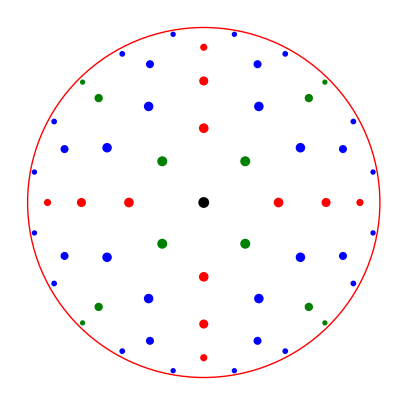

In [62]:
import matplotlib.pyplot as plt

def show_disc_rule(u):
    """
    Display plot of rule u
    """
    
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.set_axis_off()

    data = extend_disc_rule(u)

    xs = data[:, 0]
    ys = data[:, 1]
    ws = data[:, 2]
    ts = data[:, 3]

    colours = ["black", "red", "green", "blue"]
    point_colors = [colours[int(t)] for t in ts]
    ax.scatter(xs, ys, s=400*ws, c=point_colors)

    circle1 = plt.Circle((0, 0), 1, color='r', fill=False)
    ax.add_patch(circle1)

show_disc_rule(kim_song_rule0)

In [79]:
def disc_int(f,u):
    """
    Compute the approximation of the integral
    """
    s = 0

    for row in u:
        x = row[0]
        y = row[1]
        w = row[2]
        s += f(x, y) * w

    return s


disc_int(lambda x,y: x**2 * y**0, kim_song_rule)

0.7853981633974481

In [123]:
def wilkinson_poly(n,epsilon):
    """
    Get the wilkinson polynomial
    """
    if epsilon == None:
        epsilon = 0

    terms = np.array([[1, -n] for n in range(1, n+1)], dtype=float)
    
    p = terms[0]

    for i in range(1, n):
        p = np.convolve(p, terms[i])

    p_e = p
    p_e[1] += epsilon
    
    return p_e


def wilkinson_roots(n,epsilon):
    """
    Get the roots of the wilkinson polynomial
    """
    return np.roots(wilkinson_poly(n, epsilon))


wilkinson_poly(3, 0.1)



array([ 1. , -5.9, 11. , -6. ])